<a href="https://colab.research.google.com/github/dummy4441/STAT-7220-Applied-Experimental-Design/blob/HW1/Personal_Copy_of_HW_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 1: Completely Randomized Designs
## Keith Gabriel Rice
### School of Data Science & Analytics
### Kennesaw State University

**DUE: February 6, 2026**

**INSTRUCTIONS:** You are a quality control analyst for a craft brewery experimenting with a new India Pale Ale (IPA). One key quality attribute of IPA is its bitterness, measured in International Bitterness Units (IBUs). The brewery wants to determine if the aging time (3, 4, or 5 weeks) affects the IBUs of the beer. To test this, the brewing team brews a single batch of the experimental IPA and divides it into aging tanks, with each tank randomly assigned to be aged for 3, 4, or 5 weeks. After aging, the IBUs of ten randomly selected bottles from each aging time are measured using a spectrophotometer. The data are in the file `IPA.xlsx`. With these data, I want you to:


**Question 1.** Briefly define the objective of this experiment

**Answer**: The objective of this experiment is to determine if aging time (3, 4, or 5 weeks) significantly affects the measured bitterness (IBUs) of the new IPA.

**Question 2.** Specify the outcome variable

**Answer**: The outcome variable in this experiment is Bitterness, measured in International Bitterness Units. This is a quantitiative measurement taken from each sampled bottle of beer.

**Question 3.** Specify the independent variable. What are some possible lurking variables?

**Answer**: The independent variable in this experiment is aging time, with three levels being: 3 weeks, 4 weeks, and 5 weeks. Possible lurking variables may include things like: Aging tank characteristics, Bottle diffrences, and storage temperature fluctuations.

**Question 4.** Briefly explain why a completely randomized design may be appropriate for this experiment.

**Answer**: In this experiment a completely randomized design is appropriate because we are testing only one factor (aging time) and random assigment helps evely distrivute lurking variables across all treatment groups.

**Question 5.** State the null and alternative hypotheses for this experiment.

**Answer**:
Null Hypothesis: There is no diffrence in mean (IBUs) among the aging times.

Alternative Hypothesis: At least one aging time has a different mean (IBU) than others.

**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?

First 5 rows
     Weeks    IBU
0  3 Weeks  39.41
1  3 Weeks  53.18
2  3 Weeks  35.31
3  3 Weeks  59.62
4  3 Weeks  40.95

Summary statistics by aging time:

         count    mean       std    min  median    max
Weeks                                                 
3 Weeks     10  49.216  8.300656  35.31  50.785  59.62
4 Weeks     10  62.751  8.250384  47.82  65.780  71.70
5 Weeks     10  69.725  5.631258  60.09  70.950  78.03 



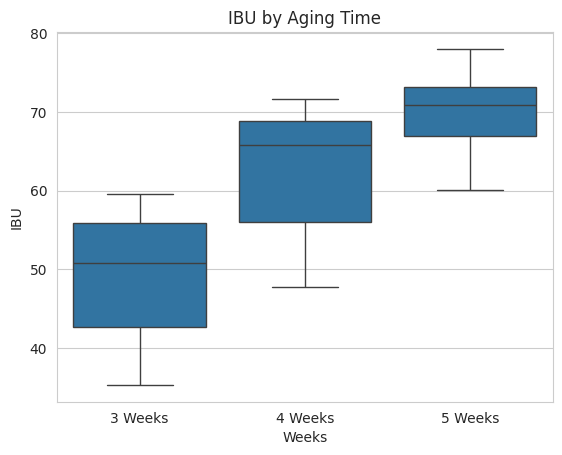

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
import seaborn as sns

data = pd.read_excel("IPA.xlsx")
print("First 5 rows")
print(data.head())

summary_stats = data.groupby('Weeks')['IBU'].agg(['count','mean','std','min','median','max'])
print("\nSummary statistics by aging time:\n")
print(summary_stats, "\n")

sns.set_style("whitegrid")

sns.boxplot(x='Weeks', y='IBU', data=data)
plt.title('IBU by Aging Time')
plt.show()


**Answer**: The box plot shows clear differences in mean IBUs across aging timessupporting the alternative hypothesis that aging time affects bitterness.

**Question 7.** Build a one-way ANOVA model. Test the assumption of normality using **both** a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?

ANOVA Table
            df      sum_sq      mean_sq          F    PR(>F)
Weeks      2.0  2174.83994  1087.419970  19.339842  0.000006
Residual  27.0  1518.12718    56.226933        NaN       NaN

QQ Plot of residuals


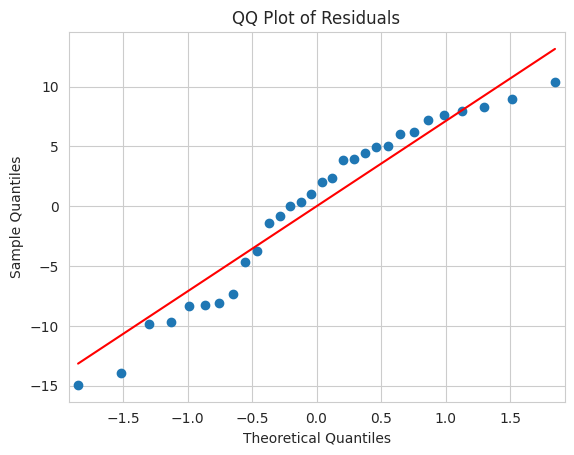

Shapiro-Wilk Test Statistic: 0.9341
Shapiro-Wilk Test P-Value: 0.0630
Fail to reject null hypothesis: Residuals are normally distributed.


In [ ]:
## Install statsmodels.api ##
#%pip install statsmodels
#%pip install scipy ##


import statsmodels.api as sm
from statsmodels.formula.api import ols
import scipy.stats as stats


mod = ols("IBU ~ Weeks", data=data).fit()

## Get the ANOVA table ##

aov_tab = sm.stats.anova_lm(mod,typ=1)

print("ANOVA Table")
print(aov_tab)

print("\nQQ Plot of residuals")
residuals = mod.resid
sm.qqplot(residuals, line='s')
plt.title("QQ Plot of Residuals")
plt.show()

## Perform Shapiro-Wilk Test of Normality ##
sw_test = stats.shapiro(residuals)
## Extract Test Stat and P-Value ##
sw_stat = sw_test.statistic
sw_pvalue = sw_test.pvalue
## Print Results ##
print(f"Shapiro-Wilk Test Statistic: {sw_stat:.4f}")
print(f"Shapiro-Wilk Test P-Value: {sw_pvalue:.4f}")
if sw_pvalue > 0.05:
    print("Fail to reject null hypothesis: Residuals are normally distributed.")
else:
    print("Reject null hypothesis: Residuals are not normally distributed.")

**Answer**: ANOVA Results:

F-statistic = 19.34, p-value = 0.000006

Statistically significant effect of aging time on IBUs

Normality Tests:

Q-Q Plot: Points follow the diagonal line reasonably well

Shapiro-Wilk: Test statistic = 0.9341, p-value = 0.0630

Conclusion: Fail to reject normality (p > 0.05)

both the visual Q-Q plot and the Shapiro-Wilk test support the assumption of normality for the residuals.

**Question 8.** Test the assumption of homogeneity of variance using **both** a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?

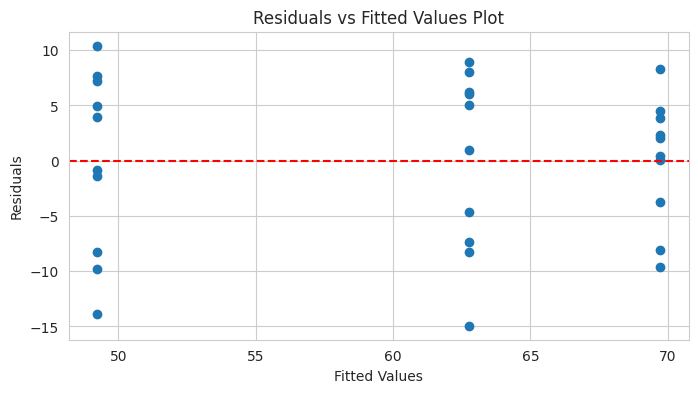


Testing method: Breusch-Pagan Test

BP Test F-statistic: 1.2952914537529732
BP Test F p-value: 0.2902941540365849
Fail to reject null hypothesis: Homoscedasticity detected. Constant Variance assumed.


In [ ]:
mod = ols("IBU ~ Weeks", data=data).fit()

# 1. Visual method: Residuals vs Fitted plot
plt.figure(figsize=(8, 4))
fitted = mod.fittedvalues
residuals = mod.resid
plt.scatter(fitted, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs Fitted Values Plot')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()


print("\nTesting method: Breusch-Pagan Test\n")
from statsmodels.stats.diagnostic import het_breuschpagan

## Run B-P Test ##
bp_test = het_breuschpagan(mod.resid,mod.model.exog)

## Extract F-statistic ##
f_statistic = bp_test[2]

## Extract its P-Value ##
f_p_value = bp_test[3]

print(f"BP Test F-statistic: {f_statistic}")
print(f"BP Test F p-value: {f_p_value}")
if f_p_value > 0.05:
    print("Fail to reject null hypothesis: Homoscedasticity detected. Constant Variance assumed.")
else:
    print("Reject null hypothesis: Heteroscedasticity detected. Constant Variance not assumed.")


**Answer**: Yes. Both the visual inspection (random scatter in residuals vs fitted plot) and the Breusch-Pagan test (p = 0.290 > 0.05) support the assumption of homogeneity of variance.

**Question 9.** Report the F-statistic and its associated p-value from the one-way ANOVA model. Which of our two hypotheses is more strongly supported? Why?

**Answer**:
F-statistic: 19.34,
P-value: 0.000006. The Alternative hypothesis is more strongly supported.

This is mainly because of the extremely small p-value (0.000006) which is alot less then 0.05. This greatly supports the alternative hypothesis.

**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which aging times are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
3 Weeks 4 Weeks   13.535 0.0011  5.2205 21.8495   True
3 Weeks 5 Weeks   20.509    0.0 12.1945 28.8235   True
4 Weeks 5 Weeks    6.974 0.1131 -1.3405 15.2885  False
------------------------------------------------------


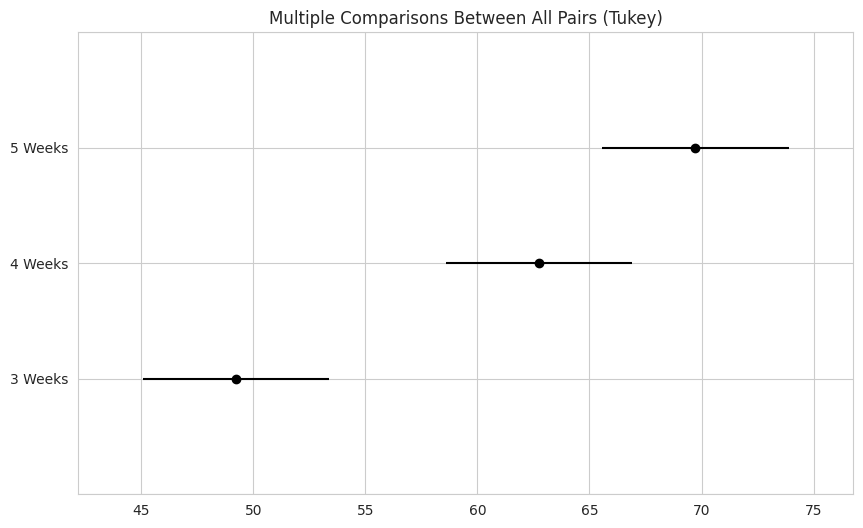

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## Perform Tukey's HSD test ##

tukey_result = pairwise_tukeyhsd(data['IBU'], data['Weeks'], alpha=0.05)

tukey_result.plot_simultaneous()
print(tukey_result)


**3 Weeks vs 4 Weeks: **

Mean difference: 13.535 IBUs

P-value: 0.0011

Significantly different (reject = True)

**3 Weeks vs 5 Weeks:**

Mean difference: 20.509 IBUs

P-value: 0.0000

Significantly different (reject = True)

**4 Weeks vs 5 Weeks:**

Mean difference: 6.974 IBUs

P-value: 0.1131

NOT significantly different (reject = False)

**Answer**: Bitterness increases significantly from 3 to 4 weeks and from 3 to 5 weeks, but the difference between 4 and 5 weeks is not statistically significant.


**Question 11.** Write a brief, contextual conclusion summarizing the results of your analyses. Additionally, describe any limitations of the experiment and/or your analyses, and suggest potential improvements for future experiments of this nature.


**Conclusion**: Aging time significantly affects the bitterness of the new experimental IPA. Beers aged 4 and 5 weeks have significantly higher IBUs than those aged only 3 weeks. However there is no statistically significant diffrence in bitterness between 4 and 5 weeks of aging.

Some possible limitations of this experiment may include: Limited aging times, Small sample size, and Lack of laboratory measurements.

Similarily some possible improvements of this project for future experiments may include: Additional aging times, Larger sample size, Provided laboratory specifications, and Randomized sampling.